<a href="https://colab.research.google.com/github/xaximpvp2/master/blob/main/codigo_aula_redes_neurais_parte3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Equipamento com defeito

Neste código nós construíremos uma pequena rede neural para resolver um problema de classificação

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)


## Conjunto de dados

Abaixo nós definimos uma função que permite criar dados para um equipamento que precisa operar dentro de uma certa faixa de temperatura e pressão para estar em condição saudável de operação.

In [ ]:
def cria_dados_equipamento():
    """ Cria um conjunto de dados para um equipamento com defeito ou não.
        Intervalo de pressão: 12-15 Pa é um intervalo normal de operação
        Intervalo de temperatura: 175-260C é um intervalo normal de operação
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1,2)
    X[:,1] = X[:,1] * 4 + 11.5
    X[:,0] = X[:,0] * (285-150) + 150
    Y = np.zeros(len(X))

    i=0
    for t,d in X:
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d<=y ):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y.reshape(-1,1))


In [ ]:
X,Y = cria_dados_equipamento();
print(X.shape, Y.shape)

(200, 2) (200, 1)


Abaixo plotamos os dados do equipamento. As duas características são a temperatura em graus Celsius e pressão em Pa.

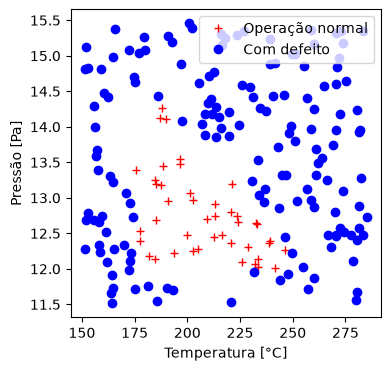

In [ ]:
pos = Y.reshape(-1,) == 1 # identifica os elementos em y que são iguais a 1
neg = Y.reshape(-1,) == 0 # identifica os elementos em y que são iguais a 0

fig,ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(X[pos,0], X[pos,1], 'r+', label="Operação normal")
ax.plot(X[neg,0], X[neg,1], 'bo', label="Com defeito")

#ax.axis([0, 4, 0, 3.5])
ax.set_ylabel('Pressão [Pa]')
ax.set_xlabel('Temperatura [°C]')
ax.legend(loc="upper right")
plt.show()

## Modelo base

In [ ]:
Y_flat = Y.reshape(-1,).astype(int)

contagem = np.bincount(Y_flat)

n_classe_0 = contagem[0]
n_classe_1 = contagem[1]

print(f"Amostras da classe 0: {n_classe_0}")
print(f"Amostras da classe 1: {n_classe_1}")

classe_majoritaria = np.argmax(contagem)

acuracia_baseline = np.mean(Y_flat == classe_majoritaria)

print(f"\nClasse majoritária: {classe_majoritaria}")
print(f"Acurácia do modelo que sempre prevê {classe_majoritaria} (modelo base): "
      f"{acuracia_baseline:.4f}")
print(f"Acurácia (taxa de acerto): {100*acuracia_baseline:.2f}%")

Amostras da classe 0: 157
Amostras da classe 1: 43

Classe majoritária: 0
Acurácia do modelo que sempre prevê 0 (modelo base): 0.7850
Acurácia (taxa de acerto): 78.50%


## Modelo obtido pelo Sci-kit learn (sem escalonar as características)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Criar a rede neural
modelo = MLPClassifier(
    hidden_layer_sizes=(3,),
    activation='logistic',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42
)

# Treinar
modelo.fit(X, Y.reshape(-1,))

# Previsões
Y_pred = modelo.predict(X)

# Acurácia
acuracia = modelo.score(X, Y.reshape(-1,))

print(f"Acurácia = {100*acuracia:.4f} %")

Acurácia = 78.5000 %


## Modelo obtido pelo Sci-kit Learn escalonando as características

In [ ]:
print(f"Temperatura Max, Min pré escalonamento: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Pressão     Max, Min pré escalonamento: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")

# Padronização das entradas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Temperatura Max, Min pós escalonamento: {np.max(X_scaled[:,0]):0.2f}, {np.min(X_scaled[:,0]):0.2f}")
print(f"Pressão     Max, Min pós escalonamento: {np.max(X_scaled[:,1]):0.2f}, {np.min(X_scaled[:,1]):0.2f}")

Temperatura Max, Min pré escalonamento: 284.99, 151.32
Pressão     Max, Min pré escalonamento: 15.45, 11.51
Temperatura Max, Min pós escalonamento: 1.66, -1.69
Pressão     Max, Min pós escalonamento: 1.79, -1.70


In [ ]:
# Criar a rede neural
modelo = MLPClassifier(
    hidden_layer_sizes=(3,),
    activation='logistic',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=2000,
    random_state=42
)

# Treinar
modelo.fit(X_scaled, Y.reshape(-1,))

# Previsões
Y_pred = modelo.predict(X_scaled)

# Acurácia
acuracia = modelo.score(X_scaled, Y.reshape(-1,))

print(f"Acurácia = {100*acuracia:.4f} %")

Acurácia = 93.5000 %


### Replicando os dados 1000 vezes para que o modelo fique mais exposto a esses dados

Abaixo nós estamos duplicando nosso conjunto de dados de treinamento em 1000 vezes, passando de 200 amostras para 200000. Essa estratégia pode ser interessante sempre que o número de amostras no conjuto de dados de treinamento for pequeno ($<1000$, por exemplo).

In [ ]:
X_maior = np.tile(X_scaled,(1000,1))
Y_maior = np.tile(Y,(1000,1))

print(X_maior.shape, Y_maior.shape)

(200000, 2) (200000, 1)


In [ ]:
# Criar a rede neural
modelo = MLPClassifier(
    hidden_layer_sizes=(3,),
    activation='logistic',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42
)

# Treinar
modelo.fit(X_maior, Y_maior.reshape(-1,))

# Previsões
Y_pred = modelo.predict(X_maior)

# Acurácia
acuracia = modelo.score(X_maior, Y_maior.reshape(-1,))

print(f"Acurácia = {100*acuracia:.4f} %")

Acurácia = 100.0000 %


## Obtendo um modelo via Tensorflow (usando características escalonadas)

### Modelo

Vamos agora construir uma rede neural via tensorflow.
Usaremos duas camadas com ativações do tipo sigmoide, conforme mostrado abaixo.

In [ ]:
numero_de_caracteristicas = X_maior.shape[1]

modelo = Sequential(
    [
        tf.keras.Input(shape=(numero_de_caracteristicas,)),
        Dense(3, activation='sigmoid', name = 'camada1'),
        Dense(1, activation='sigmoid', name = 'camada2')
     ]
)

>**OBS:** O comando `tf.keras.Input(shape=(numero_de_caracteristicas,)),`
especifica o shape esperado para a entrada da rede neural. Isso permite que o Tensorflow já saiba o número de parâmetros $w$ e $b$ da rede antecipadamente. Na prática, esse comando pode ser omitido. Nesse caso, o Tensorflow irá ajustar o número de entradas da rede quando os dados de entrada forem especificados pelo comando `modelo.fit`.

O comando `modelo.summary()` nos fornece uma descrição da rede que acabamos de criar:

In [ ]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ camada1 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ camada2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

A contagem de parâmetros mostrada acima corresponde ao número de elementos nas arrays de peso e de bias conforme mostrado abaixo.

In [ ]:
param_camada1 = 2 * 3 + 3   # parâmetros W1 + parâmetros b1
param_camada2 = 3 * 1 + 1   # parâmetros W2 + parâmetros b2
print("Número de parâmetros camada 1 = ", param_camada1, ", Número de parâmetros camada 1 = ", param_camada2  )

Número de parâmetros camada 1 =  9 , Número de parâmetros camada 1 =  4


Vamos examinar os valores que o Tensorflow usou para inicializar os pesos da nossa rede.  O shape dos pesos $W$ numa camada da rede deve ser (número de características na sua entrada, número de unidades/neurônios na camada).
Já o shape dos termos de bias $b$ de uma camada deve ser igual ao número de unidades/neurônios presente na camada.
- Na primeira camada da nossa rede, que possui 3 unidades/neurônios, esperamos que $W$ tenha tamanho (2,3) e que $b$ tenha 3 elementos.
- Na segunda camada da nossa rede, que possui apenas 1 unidade/neurônio, esperamos que $W$ tenha tamanho (3,1) e $b$ tenha 1 elemento.

In [ ]:
W1, b1 = modelo.get_layer("camada1").get_weights()  # acessando os parâmetros da camada 1
W2, b2 = modelo.get_layer("camada2").get_weights()  # acessando os parâmetros da camada 2
print(f"W1{W1.shape}:\n", W1, f"\nb1{b1.shape}:", b1)
print(f"W2{W2.shape}:\n", W2, f"\nb2{b2.shape}:", b2)

W1(2, 3):
 [[-0.80290127  0.22327232 -0.32263064]
 [ 0.2660339  -0.2298727  -0.50641155]] 
b1(3,): [0. 0. 0.]
W2(3, 1):
 [[0.23695982]
 [0.8713697 ]
 [0.29632294]] 
b2(1,): [0.]


Os 2 comandos usados a seguir serão explicados em mais detalhes nas aulas seguintes. Por enquanto, basta sabermos que:
- O comando `modelo.compile` irá definir a função de perda e irá especificar o tipo de otimização utilizada.
- O comando `modelo.fit` roda o Método do Gradiente para ajustar os parâmetros do modelo aos dados.

In [ ]:
modelo.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
)

modelo.fit(
    X_maior,Y_maior,
    epochs=10,
)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.2162
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.1218
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.1031
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.0248
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0142
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0098
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0071
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0051
Epoch 9/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0037
Epoch 10/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0028


#### Parâmetros atualizados:

Agora que já treinamos o modelo, note que os valores dos seus 13 parâmetros foram atualizados:

In [ ]:
W1, b1 = modelo.get_layer("camada1").get_weights()
W2, b2 = modelo.get_layer("camada2").get_weights()
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[14.605585   12.601607   -0.03056852]
 [12.170094    0.31896362 -9.017011  ]] 
b1: [  1.7946686  13.132513  -11.278875 ]
W2:
 [[-41.31488 ]
 [ 37.401447]
 [-43.92819 ]] 
b2: [-12.146651]


#### Lotes e épocas

O método do **gradiente clássico** que estudamos até agora usava, em cada iteração, todas as amostras do conjunto de dados de treinamento para realizar um passo de atualização dos parâmetros da rede.

Acontece que esse método clássico é muito custoso computacionalmente. Basta você pensar que, se o número de exemplos de treinamento é grande (por exemplo, 200 mil), cada amostra com 2 características, pelo menos 400 mil valores são computados em cada iteração.

Buscando tornar o processo de treinamento do modelo mais eficiente computacionalmente, surgiu o **método do gradiente em mini-lotes** (ou, em inglês, mini-batch gradient descent).

No método do gradiente em mini-lotes, o conjunto de dados de treinamento é dividido em 'lotes de amostras'. O tamanho padrão de cada lote no Tensorflow é de 32 exemplos de treinamento.
Como há 200000 amostras no nosso conjunto de dados expandido, isso significa que teremos 200000/32=6250 lotes.
Assim, em cada iteração, o método do gradiente opera em cima de apenas um desses lotes de amostras, passando para o lote seguinte na iteração seguinte.

Ao passar por todos os 6250 mini-lotes de amostra, significa que o método do gradiente completou sua primeira 'varredura' em cima do conjunto completo de dados. O número de varreduras que é feita em cima de todos os dados é também chamado de 'número de épocas'.


Com o comando `fit` acima, note que o número de épocas foi definido como sendo 10. Isso significa que o conjunto completo de dados foi aplicado ("varrido") 10 vezes no processo de treinamento do modelo. Durante o treinamento do modelo, o progresso de treinamento é mostrado conforme abaixo:
```
Epoch 1/10
6250/6250 [==============================] - 6s 910us/step - loss: 0.1782
```
A primeira linha, `Epoch 1/10`, descreve a época na qual o modelo encontra-se rodando atualmente em relação ao total.

#### Carregando um conjunto de pesos conhecidos

A seguir, nós carregamos alguns pesos salvos a partir de um treinamento feito anteriormente. Isso é para que este notebook torne-se robusto a mudanças do Tensorflow ao longo do tempo. Cada vez que rodamos o Tensorflow para um problema podemos obter pesos diferentes.

Sinta-se livre para rodar novamente o código considerando os próprios parâmetros que você treinou para a rede, comparando então os resultados.

In [ ]:
W1 = np.array([
    [-8.94,  0.29, 12.89],
    [-0.17, -7.34, 10.79]] )
b1 = np.array([-9.87, -9.28,  1.01])
W2 = np.array([
    [-31.38],
    [-27.86],
    [-32.79]])
b2 = np.array([15.54])
modelo.get_layer("camada1").set_weights([W1,b1])
modelo.get_layer("camada2").set_weights([W2,b2])

### Previsões com o modelo

Uma vez que você treinou o modelo, você pode então usá-lo para realizar previsões.
Lembre-se que a saída do nosso modelo é uma probabilidade. Nesse caso, é a probabilidade de uma boa torra para o café. Para tomar uma decisão, precisamos aplicar um valor de limiar à probabilidade. Nesse caso, vamos usar um limiar de 0.5.

O modelo recebe um ou mais exemplos, cada exemplo numa linha da matriz. Nesse caso, nós temos duas características, tal que a matriz será (m,2), onde m é o número de exemplos que usaremos no nosso modelo.


Para realizar uma previsão, usamos o comando `predict`.



In [ ]:
probabilidades = modelo.predict(X_scaled) # Xn são as características normalizadas do nosso conjunto de dados de treinamento

ychapeu = np.zeros_like(probabilidades)
for i in range(len(probabilidades)):
    if probabilidades[i] >= 0.5:
        ychapeu[i] = 1
    else:
        ychapeu[i] = 0

print("Taxa de acerto para os dados de treinamento:", (np.mean(Y == ychapeu) * 100))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Taxa de acerto para os dados de treinamento: 100.0


### Previsões com novos dados

Vamos agora criar novos dados e verificar as previsões feitas pelo modelo. Vamos começar criando os dados de entrada.

Lembre-se, nós normalizamos as características de entrada com base nos dados de treinamento. Portanto, temos que também normalizar esse nosso novo conjunto de dados de teste.

In [ ]:
X_teste = np.array([
    [200,13.9],  # exemplo positivo (espera-se que seja igual a 1)
    [200,17]])   # exemplo negativo (espera-se que seja igual a 0)
X_teste_norm    = scaler.fit_transform(X_teste)
probabilidades  = modelo.predict(X_teste_norm)
print(f"probabilidades = \n", f"{probabilidades}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
probabilidades = 
 [[9.9999410e-01]
 [3.2205726e-08]]


Ou seja, supondo uma temperatura do equipamento de 200 graus Celsius, o nosso modelo prevê:

- Uma probabilidade do equipamento estar com defeito de 96.25%, caso a pressão seja de 13.9 Pa.
- Uma probabilidade do equipamento estar com defeito praticamente 0.0%, caso a pressão seja de 17 Pa.

Para converter as probabilidade numa decisão, nós usamos um valor de limiar:

In [ ]:
ychapeu = np.zeros_like(probabilidades)
for i in range(len(probabilidades)):
    if probabilidades[i] >= 0.5:
        ychapeu[i] = 1
    else:
        ychapeu[i] = 0
print(f"decisões = \n{ychapeu}")

decisões = 
[[1.]
 [0.]]


Também podemos fazer isso de forma mais sucinta:

In [ ]:
ychapeu = (probabilidades >= 0.5).astype(int)
print(f"decisões = \n{ychapeu}")

decisões = 
[[1]
 [0]]


Plotando a fronteira de decisão:

In [ ]:
def plota_fronteira_decisao_nn(modelo, X, Y):

    # Identifica as classes
    pos = Y.reshape(-1,) == 1
    neg = Y.reshape(-1,) == 0

    # Cria a figura
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    # Plota os dados
    ax.plot(X[pos, 0], X[pos, 1], 'r+', label="Operação normal")
    ax.plot(X[neg, 0], X[neg, 1], 'bo', label="Com defeito")

    # Define os limites da região de plotagem
    x_min = X[:, 0].min()
    x_max = X[:, 0].max()
    y_min = X[:, 1].min()
    y_max = X[:, 1].max()

    # Cria uma grade de pontos
    u = np.linspace(x_min, x_max, 200)
    v = np.linspace(y_min, y_max, 200)

    U, V = np.meshgrid(u, v)

    # Transforma a grade em uma matriz de duas colunas:
    # [temperatura, pressão]
    X_grade = np.c_[U.ravel(), V.ravel()]

    # Calcula a saída da rede neural para todos os pontos
    Z = modelo.predict(X_grade, verbose=0)

    # Volta para o formato da grade
    Z = Z.reshape(U.shape)

    # Desenha a fronteira de decisão: probabilidade = 0.5
    ax.contour(
        U,
        V,
        Z,
        levels=[0.5],
        colors='g'
    )

    ax.set_ylabel('Pressão Escalonada [Pa]')
    ax.set_xlabel('Temperatura Escalonada [°C]')

    ax.legend(loc="upper right")

    plt.show()

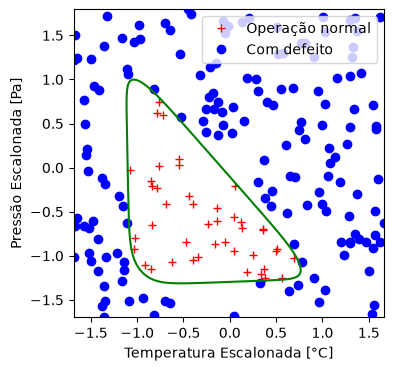

In [ ]:
plota_fronteira_decisao_nn(modelo, X_scaled, Y)

## Parabéns!

Você criou e treinou uma pequena rede neural usando Tensorflow.
A rede demonstrou a habilidade das redes neurais em lidar com decisões complexas dividindo as decisões entre múltiplas unidades (neurônios).